# Project 1: Subscription Churn Optimization System
# Framework: Thinking Like a Data Scientist

# 1. Business Problem Framing


# Real Business Problem: The platform is losing subscribers, which directly reduces recurring monthly revenue and spikes customer acquisition costs. 

# Data Science Translation: This is a Supervised Binary Classification task. We want to predict if an active customer will churn ($Y = 1$) or stay ($Y = 0$).

# Business Objective: Identify high-risk subscribers early so retention teams can target them with incentives, aiming to reduce overall churn by 15%.

# Expected Output: A risk probability score (0.0 to 1.0) for every active user ID, along with key reasons explaining why they might leave.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Setting up visual and clean theme.
sns.set_theme(style="whitegrid")
%matplotlib inline

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
import os
if os.path.exists('train.csv'):
    df = pd.read_csv('train.csv')
    test_df = pd.read_csv('test.csv')
    print("Successfully loaded from csv!")
elif os.path.exists('train.xlsx'):
    df = pd.read_excel('train.xlsx')
    test_df = pd.read_excel('test.xlsx')
    print("Successfully loaded datasets from excel files!")
else:
    print("Error!")
print(f"Training Rows: {df.shape[0]} | Columns: {df.shape[1]}")

Successfully loaded from csv!
Training Rows: 243787 | Columns: 21


In [5]:
df.head()

,AccountAge,MonthlyCharges,TotalCharges,SubscriptionType,PaymentMethod,PaperlessBilling,ContentType,MultiDeviceAccess,DeviceRegistered,ViewingHoursPerWeek,...,ContentDownloadsPerMonth,GenrePreference,UserRating,SupportTicketsPerMonth,Gender,WatchlistSize,ParentalControl,SubtitlesEnabled,CustomerID,Churn
0,20,11.055215,221.104302,Premium,Mailed check,No,Both,No,Mobile,36.758104,...,10,Sci-Fi,2.176498,4,Male,3,No,No,CB6SXPNVZA,0
1,57,5.175208,294.986882,Basic,Credit card,Yes,Movies,No,Tablet,32.450568,...,18,Action,3.478632,8,Male,23,No,Yes,S7R2G87O09,0
2,73,12.106657,883.785952,Basic,Mailed check,Yes,Movies,No,Computer,7.395160,...,23,Fantasy,4.238824,6,Male,1,Yes,Yes,EASDC20BDT,0
3,32,7.263743,232.439774,Basic,Electronic check,No,TV Shows,No,Tablet,27.960389,...,30,Drama,4.276013,2,Male,24,Yes,Yes,NPF69NT69N,0
4,57,16.953078,966.325422,Premium,Electronic check,Yes,TV Shows,No,TV,20.083397,...,20,Comedy,3.616170,4,Female,0,No,No,4LGYPK7VOL,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243787 entries, 0 to 243786
Data columns (total 21 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   AccountAge                243787 non-null  int64  
 1   MonthlyCharges            243787 non-null  float64
 2   TotalCharges              243787 non-null  float64
 3   SubscriptionType          243787 non-null  object 
 4   PaymentMethod             243787 non-null  object 
 5   PaperlessBilling          243787 non-null  object 
 6   ContentType               243787 non-null  object 
 7   MultiDeviceAccess         243787 non-null  object 
 8   DeviceRegistered          243787 non-null  object 
 9   ViewingHoursPerWeek       243787 non-null  float64
 10  AverageViewingDuration    243787 non-null  float64
 11  ContentDownloadsPerMonth  243787 non-null  int64  
 12  GenrePreference           243787 non-null  object 
 13  UserRating                243787 non-null  f

In [7]:
## 2. Exploratory Data Analysis (EDA)

--- Class Counts ---
Churn
0    199605
1     44182
Name: count, dtype: int64

--- Percentage Breakdown ---
Churn
0    81.876802
1    18.123198
Name: proportion, dtype: float64


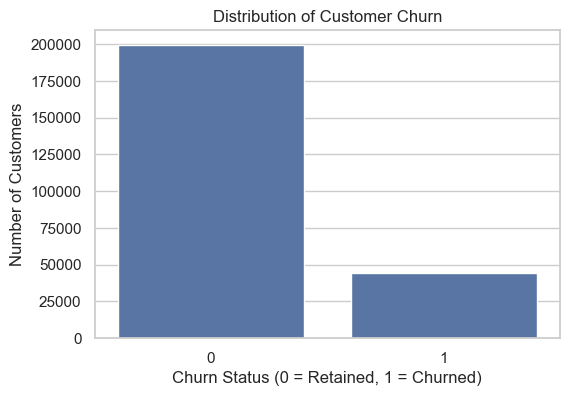

In [8]:
# Checks exact values for churn ie (0 = Stayed, 1 = Churned)
print(" Class Counts ")
print(df['Churn'].value_counts())
print("\n Percentage Breakdown ")
print(df['Churn'].value_counts(normalize=True) * 100)

# Ploting a bar chart for clear visuals
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df)
plt.title('Distribution of Customer Churn')
plt.xlabel(' Status for churn (0 = Retained, 1 = Churned)')
plt.ylabel('Number of Customers')
plt.show()

--- Average Support Tickets per Month ---
Churn
0    4.390576
1    5.017451
Name: SupportTicketsPerMonth, dtype: float64


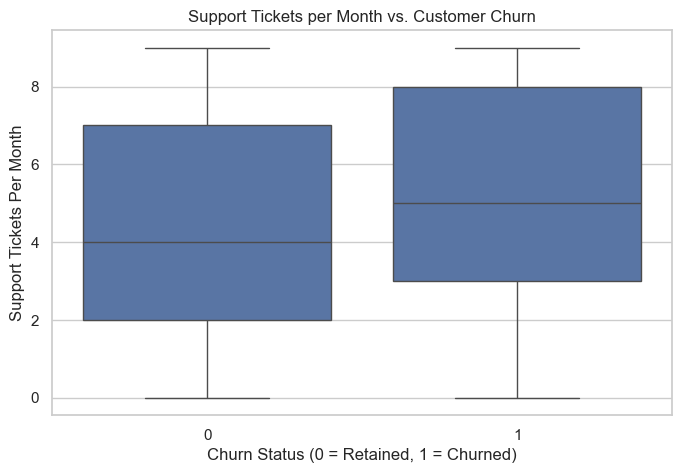

In [9]:
print("--- Average Support Tickets per Month ---")
print(df.groupby('Churn')['SupportTicketsPerMonth'].mean())

# Ploting the figure
plt.figure(figsize=(8, 5))
sns.boxplot(x='Churn', y='SupportTicketsPerMonth', data=df)
plt.title('Support Tickets per Month vs. Customer Churn')
plt.xlabel('Churn Status (0 = Retained, 1 = Churned)')
plt.ylabel('Support Tickets Per Month')
plt.show()

In [12]:
# 3. Data Preprocessing & Feature Engineering

# Before training our machine learning models, we must clean and transform our features:
# 1. Drop Unnecessary Columns: Remove identifiers like `CustomerID` that contain no predictive value.
# 2. Categorical Encoding: Convert text-based columns (like `SubscriptionType` and `PaymentMethod`) into numeric values using One-Hot Encoding.
# 3. Train-Test Alignment: Prepare our features ($X$) and target ($y$) arrays.

In [15]:
# Drop CustomerID
X = df.drop(columns=['CustomerID', 'Churn'])
y = df['Churn']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

Features (X) shape: (243787, 19)
Target (y) shape: (243787,)


In [14]:
# Convert all remaining text/object columns into numeric columns (0s and 1s)
X_encoded = pd.get_dummies(X, drop_first=True)

# Verify the changes
print("Original Features shape:", X.shape)
print("Encoded Features shape:", X_encoded.shape)
print("\nFirst 10 columns after encoding:")
print(list(X_encoded.columns[:10]))

Original Features shape: (243787, 19)
Encoded Features shape: (243787, 28)

First 10 columns after encoding:
['AccountAge', 'MonthlyCharges', 'TotalCharges', 'ViewingHoursPerWeek', 'AverageViewingDuration', 'ContentDownloadsPerMonth', 'UserRating', 'SupportTicketsPerMonth', 'WatchlistSize', 'SubscriptionType_Premium']


In [17]:
# 4. Model Training & Selection
# Random Forest Classifier: Ensemble method builds multiple decision trees to find complex patterns in customer churn behaviors

In [19]:
from sklearn.ensemble import RandomForestClassifier
import time

print("Training the Random Forest model on 243,787 rows....")
start_time = time.time()

# Initialize Random Forest
# n_estimators=50 builds 50 decision trees
# max_depth=10 to keep the trees structured and to run efficiently and prevent overfitting
# n_jobs=-1 uses all your laptop's CPU cores to speed things up
rf_model = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)

rf_model.fit(X_encoded, y)

end_time = time.time()
print(f"Model training complete.. Time taken: {end_time - start_time:.2f} seconds.")

Training the Random Forest model on 243,787 rows....
Model training complete.. Time taken: 6.36 seconds.


In [23]:
# Extracts features.
importances = rf_model.feature_importances_
feature_names = X_encoded.columns

# DataFrame to store and sort features by their importance value
feature_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Display the top 10 most critical drivers of churn
print(" Top 10 Most Critical Drivers of Churn ")
print(feature_imp_df.head(10))


 Top 10 Most Critical Drivers of Churn 
                    Feature  Importance
0                AccountAge    0.224816
4    AverageViewingDuration    0.168449
3       ViewingHoursPerWeek    0.135923
5  ContentDownloadsPerMonth    0.120117
1            MonthlyCharges    0.104974
2              TotalCharges    0.102953
7    SupportTicketsPerMonth    0.046819
6                UserRating    0.029715
8             WatchlistSize    0.015939
9  SubscriptionType_Premium    0.006076


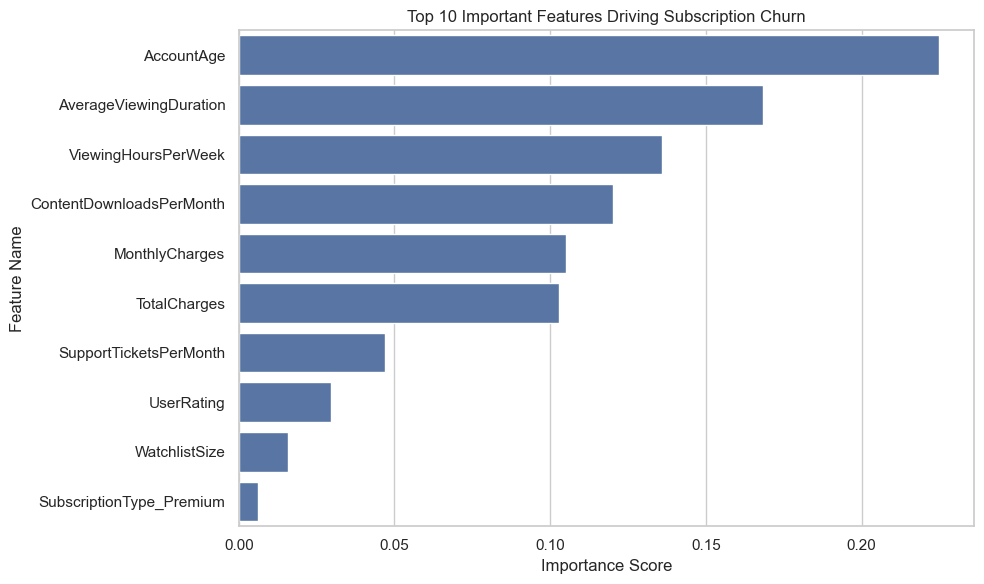

In [25]:
# Top 10 features.
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df.head(10))
plt.title('Top 10 Important Features Driving Subscription Churn')
plt.xlabel('Importance Score')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

In [31]:
# Prediction
X_test = test_df.drop(columns=['CustomerID'])
X_test_encoded = pd.get_dummies(X_test, drop_first=True)
X_test_encoded = X_test_encoded.reindex(columns=X_encoded.columns, fill_value=0)

# Generate the predictions and probabilities.
test_df['Churn_Probability'] = rf_model.predict_proba(X_test_encoded)[:, 1]
test_df['Predicted_Action'] = rf_model.predict(X_test_encoded)

print("Final Business Output Delivery")
test_df[['CustomerID', 'Churn_Probability', 'Predicted_Action']].head(10)

Final Business Output Delivery


,CustomerID,Churn_Probability,Predicted_Action
0,O1W6BHP6RM,0.149125,0
1,LFR4X92X8H,0.054541,0
2,QM5GBIYODA,0.268163,0
3,D9RXTK2K9F,0.100979,0
4,ENTCCHR1LR,0.151542,0
5,7A88BB5IO6,0.347050,0
6,70OMW9XEWR,0.112103,0
7,EL1RMFMPYL,0.162085,0
8,4IA2QPT6ZK,0.189808,0
9,AEDCWHSJDN,0.147306,0
